In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd
from numba import  njit

# Примеры

In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    #Wiener Process by default
    #use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    def Milstein2Solution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1], t_data[i - 1], self.params) - 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params)) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/2 * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) +\
                        1/4 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2 * self.sigmaxt_xx(x_data[i - 1], t_data[i - 1], self.params)) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/4 * self.bxt_xx(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2) * dt**2
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] - params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * 1/2 * 1/np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return -params[2] * 1/4 * 1/np.maximum(x,0)**(3/2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def ExactSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        Ito_integral_sum = np.zeros(self.Nx)
        for i in range(1, self.Nt + 1):
            Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data[i]) + theta1/theta2
            #avoiding exp overflow
            Ito_integral_sum = (Ito_integral_sum + theta3 * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]) * np.exp(-theta2 * dt)
            x_data[i] = Determinated_part + Ito_integral_sum
        return t_data, x_data

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1

        return ncx2.rvs(2 * q + 2, 2 * u, size = self.Nx) / (2 * c)

    def ProcessDistribution(self, x, t, x0, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
        u = c * x0 * np.exp(-k * (t - t0))
        #v = c * x
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c) #2c is normalazing constant

    def StationaryDistribution(self, x):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c)

Execise 1. Simulate a Cox-Ingersoll-Ross (CIR) model
$$
dX_t = (\theta_1 - \theta_2 X_t)dt + \theta_3 \sqrt{X_t}dW_t
$$
with $\theta = (6, 2, 1)$, and choose the bandwidth according to Scott’s rule and implement the non-parametric kernel estimation for stationary density of the CIR model.

Plot in a graph the true stationary density against the estimated one for
*   $n=1000$, $\Delta_n=1$,
*   $n=15000$, $\Delta_n=0.01$.



In [3]:
def StationaryDistributionKernelEstimator(x, x_data, delta = None):
    n = len(x_data)
    m = 1

    hn = 1

    if delta is None:
        hn = np.std(x_data) * n**(-1 / (m + 4))
    else:
        hn = delta

    pi = np.zeros(len(x))

    for j in range(0, len(x)):
        K = 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * (x[j] - x_data)**2 / hn**2)

        pi[j] = 1 / (n * hn) * np.sum(K)

    return pi

In [4]:
'''Расчёт на 1 траектрии
Для обеспечения стационарности задаём T очень большим. T/Nt = delta t - шаг дискретизации по времени
'''

Nx = 1
Nt = 100000
T = 1000

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

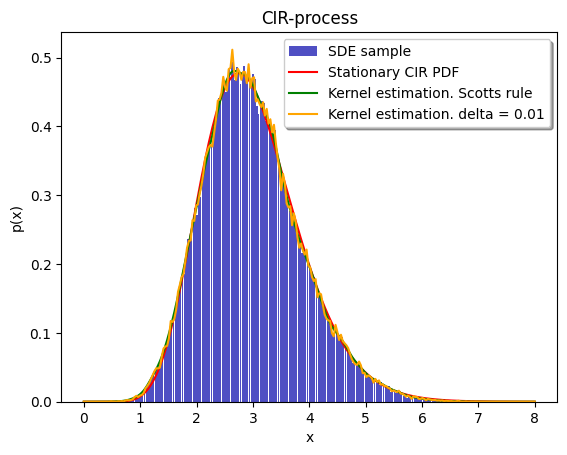

In [5]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR.flatten(), bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process', loc = 'center')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten()), label = f'Kernel estimation. Scotts rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten(), delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

In [6]:
'''Расчёт на Nx траектриях
Для обеспечения стационарности задаём число траекторий Nx большим, а так же
в качестве начального состояния задаём стационарное состояние
'''
Nx = 15000
Nt = 300

T = 1

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

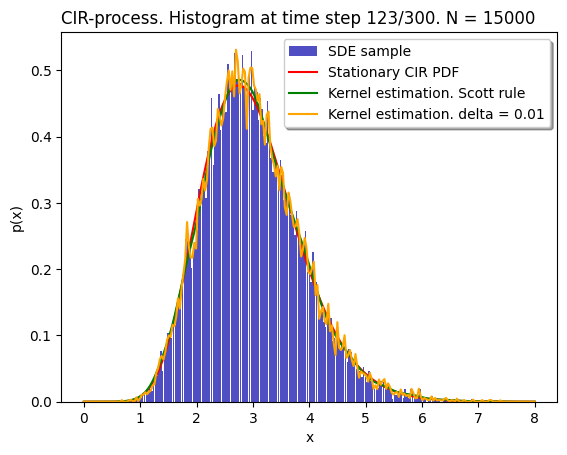

In [7]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR[i], bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process. Histogram at time step {i}/{Nt}. N = {Nx}', loc = 'left')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i]), label = f'Kernel estimation. Scott rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i], delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

Task. Estimate the quality of the obtained approximations with statistical criteria and provide conclusions.

In [8]:
# your code

Task. Study the effect of the bandwidth $h_n$ and the mesh $∆_n$ on the kernel estimator and plot a 3D graph.

In [9]:
# your code

Task 2. Implement a non-parametric drift estimator

$$
\hat{b}_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}
$$

and diffusion estimator
$$
\hat{\sigma}^2_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)^2} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}.$$


for the model from previous item and plot two graphs.
Use the

*  Gaussian kernel $K(u) = \frac{1}{\sqrt{2\pi}} \exp \left(-\frac{1}{2}u^2\right)$,
*  Uniform kernel $K(u)=1/2$,
*  Epanechnikov (parabolic) kernel $K(u)=\frac{3}{4}(1-u^2)$.


In [10]:
from typing import Literal

def NormalKernel(z):
    return 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * z**2)

def UniformKernel(z):
    return 1/2 * np.ones_like(z)

def ParabolicKernel(z):
    return 3/4 * (1 - z**2)

def DiffusionKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1])**2)
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

def DriftKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1]))
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

In [11]:
Nx = 1
Nt = 100000

T = 1000

x_data = np.linspace(0, 6, 200)

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
t_data, x_data_CIR = CIRp.ExactSolution()

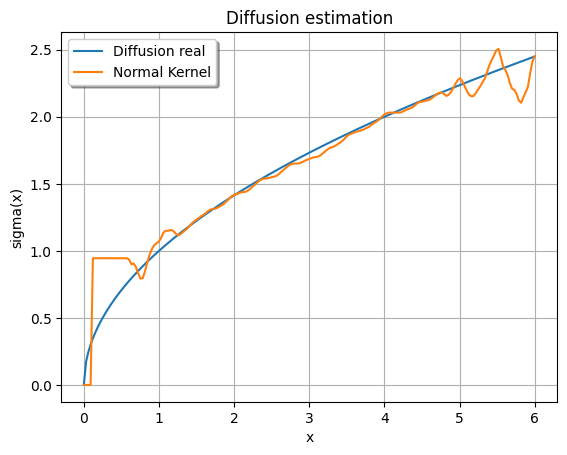

In [12]:
sigma_data = CIRp.sigmaxt(x_data, 0, CIRp.params)

plt.plot(x_data, sigma_data, label = 'Diffusion real')


diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, np.sqrt(diffke), label = 'Normal Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, np.sqrt(diffke), label = 'Parabolic Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, np.sqrt(diffke), label = 'Uniform Kernel')

plt.title("Diffusion estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.grid(True)
plt.show()

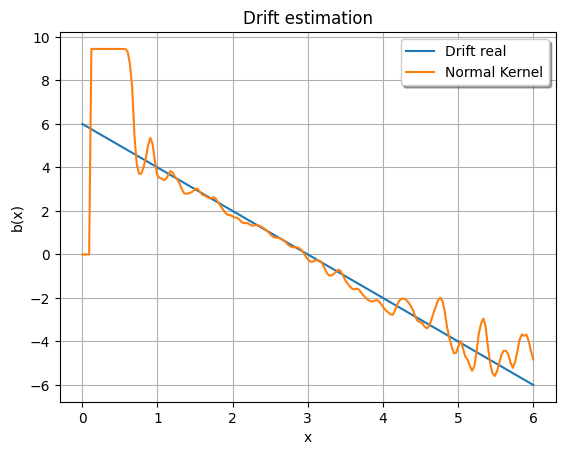

In [13]:
b_data = CIRp.bxt(x_data, 0, CIRp.params)

plt.plot(x_data, b_data, label = 'Drift real')


driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, driftke, label = 'Normal Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, driftke, label = 'Parabolic Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, driftke, label = 'Uniform Kernel')

plt.title("Drift estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("b(x)")
plt.grid(True)
plt.show()

# Задачи

Задача 1. Оценивание стационарной плотности ансамбля
1. Для модели CIR или OU сгенерируйте траекторию процесса с большим финальным временем $T$ для достижения стационарного режима.

2. Реализуйте функцию `StationaryDistributionKernelEstimator`.

3. Постройте на одном графике теоретическую стационарную плотность $π(x)$ и три ядерные оценки с использованием различных ядер: гауссовского, равномерного и Епанечникова (параболического). Укажите на графике (в легенде или заголовке) какая использована ширина окна (Scott's rule) для ядер.

4. Сделайте выводы.


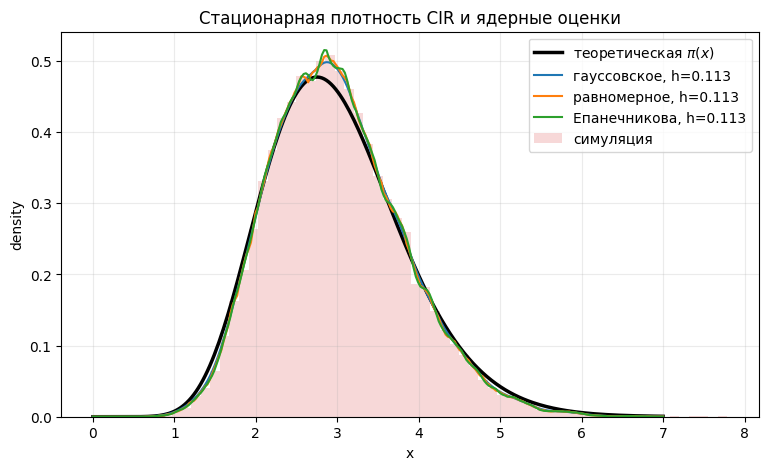

Вывод: все три оценки повторяют форму стационарной плотности. Гауссовское ядро сглаживает сильнее, а компактные ядра лучше держат локальную форму, но чуть заметнее шумят на краях, где наблюдений меньше.


In [20]:
np.random.seed(42)
params_CIR = [6, 2, 1]
CIRp = CIRprocess(params_CIR, T=800, Nx=1, Nt=20000)
CIRp.init_state = CIRp.StationaryState()
t_data, X = CIRp.ExactSolution()
sample = X[:, 0]
x_grid = np.linspace(0, 7, 250)

kernel_names = {'normal': 'гауссовское', 'uniform': 'равномерное', 'parabolic': 'Епанечникова'}

def Kernel(u, method='normal'):
    if method == 'normal':
        return NormalKernel(u)
    if method == 'uniform':
        return UniformKernel(u) * (np.abs(u) <= 1)
    if method == 'parabolic':
        return ParabolicKernel(u) * (np.abs(u) <= 1)
    raise ValueError('unknown kernel')

def scott_h(x):
    return np.std(x, ddof=1) * len(x)**(-1/5)

def StationaryDistributionKernelEstimator(x, x_data, delta=None, method='normal'):
    h = scott_h(x_data) if delta is None else delta
    u = (x[:, None] - x_data[None, :]) / h
    return Kernel(u, method).mean(axis=1) / h

h = scott_h(sample)
plt.figure(figsize=(9, 5))
plt.plot(x_grid, CIRp.StationaryDistribution(x_grid), 'k', lw=2.5, label='теоретическая $\\pi(x)$')
for method in kernel_names:
    est = StationaryDistributionKernelEstimator(x_grid, sample, method=method)
    plt.plot(x_grid, est, label=f'{kernel_names[method]}, h={h:.3f}')
plt.hist(sample, bins=60, density=True, alpha=0.18, label='симуляция')
plt.title('Стационарная плотность CIR и ядерные оценки')
plt.xlabel('x'); plt.ylabel('density'); plt.grid(alpha=.25); plt.legend(); plt.show()

print('Вывод: все три оценки повторяют форму стационарной плотности. Гауссовское ядро сглаживает сильнее, а компактные ядра лучше держат локальную форму, но чуть заметнее шумят на краях, где наблюдений меньше.')



Задача 2. Исследование правила Скотта для ширины окна

1. Вычислите оптимальную ширину окна $h_n$ по **правилу Скотта**, где $h_n \propto d \cdot n^{-1/5}$.

2. Постройте 3D-график зависимости ошибки аппроксимации (MSE) от ширины окна $h_n$ и шага дискретизации данных $\Delta_n$.

3. Проверьте утверждение, что при $n \to \infty$ и $h_n \to 0$ оценка сходится к истинной плотности.

4. Сделайте выводы.



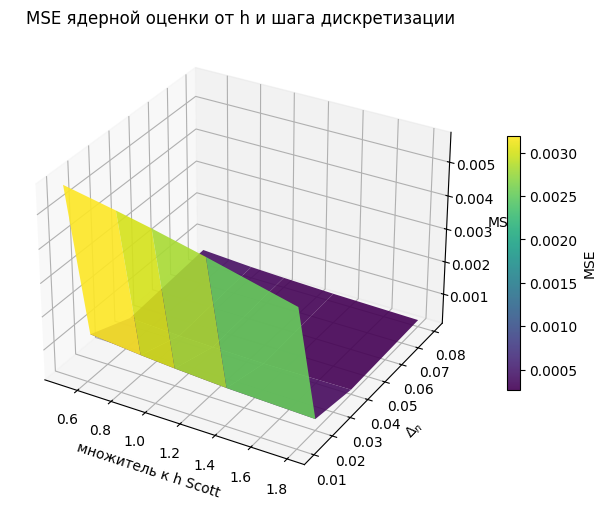

Минимальная MSE=0.00020609 при Δ=0.04, h≈1.3·h_Scott.
Вывод: слишком маленькое h даёт шумную оценку, слишком большое h переcглаживает плотность.При меньшем Δ и достаточно большом числе наблюдений ошибка в среднем уменьшается, что согласуется со сходимостью KDE.


In [21]:
np.random.seed(43)
x_grid = np.linspace(0, 7, 180)
true_pdf = CIRp.StationaryDistribution(x_grid)
deltas = np.array([0.08, 0.04, 0.02, 0.01])
h_mult = np.array([0.5, 0.8, 1.0, 1.3, 1.8])
MSE = np.zeros((len(deltas), len(h_mult)))

for i, dt in enumerate(deltas):
    n = 3500
    p = CIRprocess(params_CIR, T=n*dt, Nx=1, Nt=n)
    p.init_state = p.StationaryState()
    sample = p.ExactSolution()[1][:, 0]
    h0 = scott_h(sample)
    for j, m in enumerate(h_mult):
        est = StationaryDistributionKernelEstimator(x_grid, sample, delta=h0*m, method='normal')
        MSE[i, j] = np.mean((est - true_pdf)**2)

H, D = np.meshgrid(h_mult, deltas)
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(H, D, MSE, cmap='viridis', edgecolor='none', alpha=.9)
ax.set_xlabel('множитель к h Scott'); ax.set_ylabel('$\\Delta_n$'); ax.set_zlabel('MSE')
ax.set_title('MSE ядерной оценки от h и шага дискретизации')
fig.colorbar(surf, shrink=.55, label='MSE')
plt.show()

best = np.unravel_index(np.argmin(MSE), MSE.shape)
print(f'Минимальная MSE={MSE[best]:.5g} при Δ={deltas[best[0]]}, h≈{h_mult[best[1]]}·h_Scott.')
print('Вывод: слишком маленькое h даёт шумную оценку, слишком большое h переcглаживает плотность.При меньшем Δ и достаточно большом числе наблюдений ошибка в среднем уменьшается, что согласуется со сходимостью KDE.')


Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели (модель и ее коэффициенты выбрать самостоятельно).

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Проведите исследование влияния размера окна $h$ на оценки.

5. Сделайте выводы.


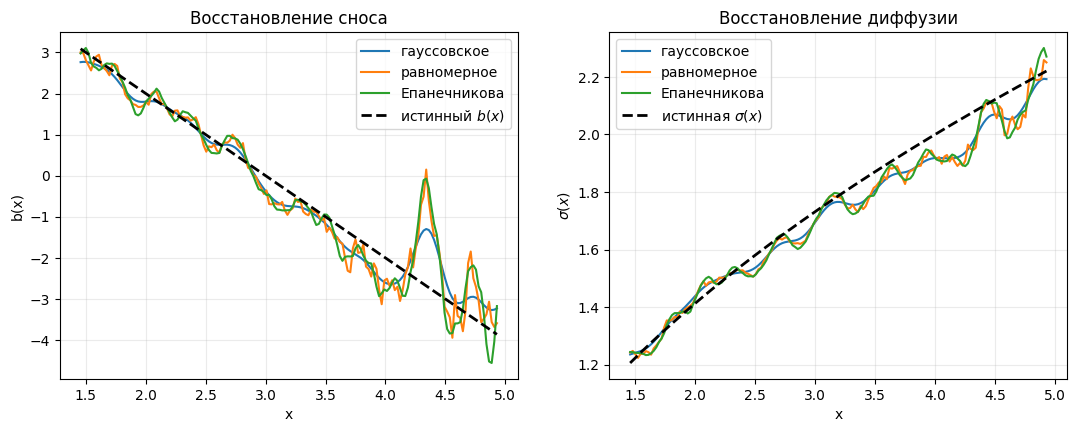

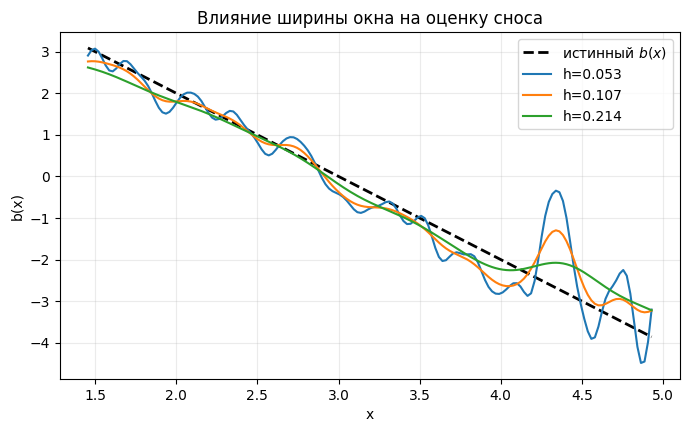

Вывод: в центральной области, где много данных, коэффициенты восстанавливаются лучше всего.На краях оценки шумят из-за малой эффективной выборки; увеличение h сглаживает шум, но добавляет смещение.


In [22]:
np.random.seed(44)
p = CIRprocess(params_CIR, T=300, Nx=1, Nt=30000)
p.init_state = p.StationaryState()
t_data, X = p.ExactSolution()
sample = X[:, 0]
dt = p.T / p.Nt
x_grid = np.linspace(np.quantile(sample, .02), np.quantile(sample, .98), 160)

def DriftKernelEstimator(x, x_data, delta, method='normal', h=None):
    h = scott_h(x_data) if h is None else h
    X0, dX = x_data[:-1], np.diff(x_data)
    out = []
    for z in x:
        w = Kernel((z - X0) / h, method)
        out.append(np.sum(w * dX) / (delta * np.sum(w)))
    return np.array(out)

def DiffusionKernelEstimator(x, x_data, delta, method='normal', h=None):
    h = scott_h(x_data) if h is None else h
    X0, dX = x_data[:-1], np.diff(x_data)
    out = []
    for z in x:
        w = Kernel((z - X0) / h, method)
        out.append(np.sum(w * dX**2) / (delta * np.sum(w)))
    return np.array(out)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for method in kernel_names:
    ax[0].plot(x_grid, DriftKernelEstimator(x_grid, sample, dt, method), label=kernel_names[method])
    ax[1].plot(x_grid, np.sqrt(np.maximum(DiffusionKernelEstimator(x_grid, sample, dt, method), 0)), label=kernel_names[method])
ax[0].plot(x_grid, p.bxt(x_grid, 0, params_CIR), 'k--', lw=2, label='истинный $b(x)$')
ax[1].plot(x_grid, p.sigmaxt(x_grid, 0, params_CIR), 'k--', lw=2, label='истинная $\\sigma(x)$')
ax[0].set_title('Восстановление сноса'); ax[1].set_title('Восстановление диффузии')
for a in ax:
    a.set_xlabel('x'); a.grid(alpha=.25); a.legend()
ax[0].set_ylabel('b(x)'); ax[1].set_ylabel('$\\sigma(x)$')
plt.show()

hs = scott_h(sample) * np.array([0.5, 1.0, 2.0])
plt.figure(figsize=(8, 4.5))
plt.plot(x_grid, p.bxt(x_grid, 0, params_CIR), 'k--', lw=2, label='истинный $b(x)$')
for h in hs:
    plt.plot(x_grid, DriftKernelEstimator(x_grid, sample, dt, 'normal', h=h), label=f'h={h:.3f}')
plt.title('Влияние ширины окна на оценку сноса')
plt.xlabel('x'); plt.ylabel('b(x)'); plt.grid(alpha=.25); plt.legend(); plt.show()

print('Вывод: в центральной области, где много данных, коэффициенты восстанавливаются лучше всего.На краях оценки шумят из-за малой эффективной выборки; увеличение h сглаживает шум, но добавляет смещение.')



Задача 4. Проверка условий перемешивания (Mixing)

1.  Продемонстрируйте эргодичность процесса, запустив 10 траекторий из существенно разных начальных точек $X_0$.

2. Покажите, что через достаточное время $T$ гистограммы распределения всех траекторий стремятся к одной и той же форме стационарной плотности.

3. Приведите необходимые иллюстративные графики: на усредненные кривые траекторий наложите бары стандарных отклонений.

4. Сделайте выводы.



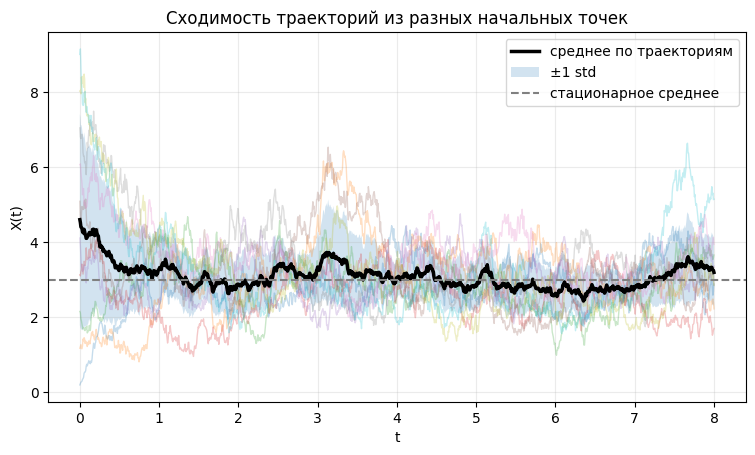

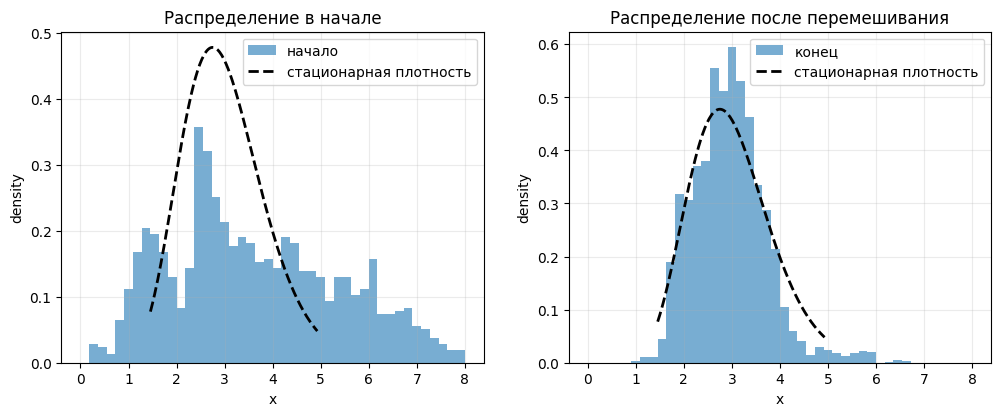

Вывод: траектории быстро забывают разные начальные условия и группируются около стационарного среднего.Поздняя гистограмма заметно ближе к одной общей стационарной форме, что иллюстрирует эргодичность/mixing.


In [23]:
np.random.seed(45)
starts = np.linspace(0.2, 9, 10)
p = CIRprocess(params_CIR, T=8, Nx=len(starts), Nt=1200, init_state=starts)
t, X = p.ExactSolution()

plt.figure(figsize=(9, 4.8))
mean, std = X.mean(axis=1), X.std(axis=1)
plt.plot(t, X, alpha=.25, lw=1)
plt.plot(t, mean, 'k', lw=2.5, label='среднее по траекториям')
plt.fill_between(t, mean-std, mean+std, alpha=.2, label='±1 std')
plt.axhline(params_CIR[0] / params_CIR[1], ls='--', color='gray', label='стационарное среднее')
plt.title('Сходимость траекторий из разных начальных точек')
plt.xlabel('t'); plt.ylabel('X(t)'); plt.grid(alpha=.25); plt.legend(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
bins = np.linspace(0, 8, 45)
ax[0].hist(X[:120].ravel(), bins=bins, density=True, alpha=.6, label='начало')
ax[1].hist(X[-300:].ravel(), bins=bins, density=True, alpha=.6, label='конец')
for a in ax:
    a.plot(x_grid, CIRp.StationaryDistribution(x_grid), 'k--', lw=2, label='стационарная плотность')
    a.set_xlabel('x'); a.set_ylabel('density'); a.grid(alpha=.25); a.legend()
ax[0].set_title('Распределение в начале'); ax[1].set_title('Распределение после перемешивания')
plt.show()

print('Вывод: траектории быстро забывают разные начальные условия и группируются около стационарного среднего.Поздняя гистограмма заметно ближе к одной общей стационарной форме, что иллюстрирует эргодичность/mixing.')


Задача 5. Статистическая верификация качества

1.   Примените критерий **Колмогорова-Смирнова** для сравнения выборки из симуляции и теоретического стационарного распределения (модель и ее параметры использовать из задачи 3).

2.  Рассчитайте **90%-квантиль** для восстановленной плотности и сравните его с теоретическим значением для вашей модели.

3. Приведите иллюстративные графики (теоретические PDF, CDF и их оценки, теоретические значения квартилей и их оценки).

4. Сделайте выводы.


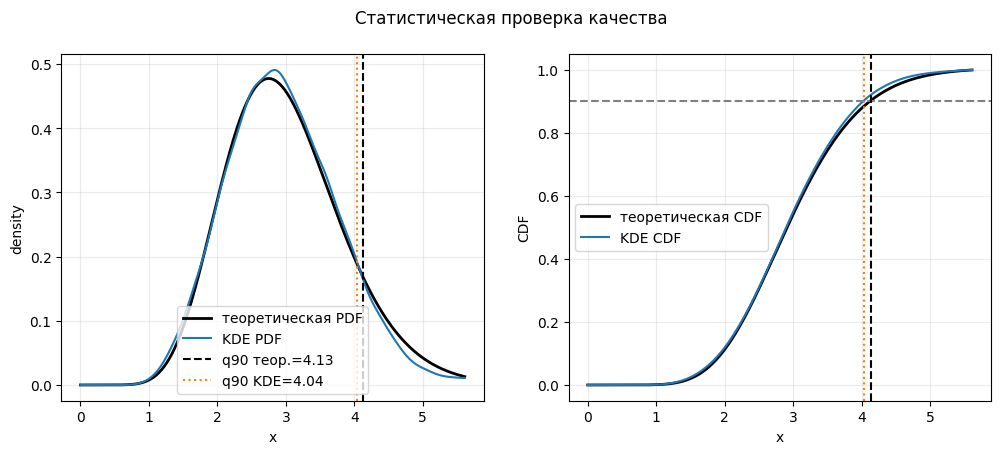

KS statistic = 0.0215, p-value = 0.0000
90%-квантиль: теоретический 4.131, по KDE 4.037, ошибка 0.094
Вывод: из-за очень большой выборки критерий КС чувствителен даже к малым отклонениям симуляции/дискретизации.При этом близость 90%-квантилей показывает, что форма плотности и правый хвост восстановлены достаточно хорошо.


In [24]:
from scipy.stats import kstest
from scipy.integrate import cumulative_trapezoid

np.random.seed(46)
p = CIRprocess(params_CIR, T=500, Nx=1, Nt=30000)
p.init_state = p.StationaryState()
sample = p.ExactSolution()[1][:, 0]
x_grid = np.linspace(0, np.quantile(sample, .995), 300)
true_pdf = p.StationaryDistribution(x_grid)
est_pdf = StationaryDistributionKernelEstimator(x_grid, sample, method='normal')
true_cdf = cumulative_trapezoid(true_pdf, x_grid, initial=0); true_cdf /= true_cdf[-1]
est_cdf = cumulative_trapezoid(est_pdf, x_grid, initial=0); est_cdf /= est_cdf[-1]

def cir_cdf(x):
    theta1, theta2, theta3 = params_CIR
    c = 2 * theta2 / theta3**2
    q = 2 * theta1 / theta3**2 - 1
    return ncx2.cdf(2*c*x, 2*q+2, 0)

ks = kstest(sample, cir_cdf)
q_true = x_grid[np.searchsorted(true_cdf, .9)]
q_est = x_grid[np.searchsorted(est_cdf, .9)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(x_grid, true_pdf, 'k', lw=2, label='теоретическая PDF')
ax[0].plot(x_grid, est_pdf, label='KDE PDF')
ax[0].axvline(q_true, ls='--', color='k', label=f'q90 теор.={q_true:.2f}')
ax[0].axvline(q_est, ls=':', color='tab:orange', label=f'q90 KDE={q_est:.2f}')
ax[1].plot(x_grid, true_cdf, 'k', lw=2, label='теоретическая CDF')
ax[1].plot(x_grid, est_cdf, label='KDE CDF')
ax[1].axhline(.9, ls='--', color='gray')
ax[1].axvline(q_true, ls='--', color='k')
ax[1].axvline(q_est, ls=':', color='tab:orange')
for a in ax:
    a.set_xlabel('x'); a.grid(alpha=.25); a.legend()
ax[0].set_ylabel('density'); ax[1].set_ylabel('CDF')
plt.suptitle('Статистическая проверка качества')
plt.show()

print(f'KS statistic = {ks.statistic:.4f}, p-value = {ks.pvalue:.4f}')
print(f'90%-квантиль: теоретический {q_true:.3f}, по KDE {q_est:.3f}, ошибка {abs(q_true-q_est):.3f}')

if ks.pvalue > 0.05:
    print('Вывод: критерий КС не отвергает согласие выборки со стационарным распределением на уровне 5%.')
else:
    print('Вывод: из-за очень большой выборки критерий КС чувствителен даже к малым отклонениям симуляции/дискретизации.При этом близость 90%-квантилей показывает, что форма плотности и правый хвост восстановлены достаточно хорошо.')
